#### Tropical Cyclone Kiko case study
Goal: repeat the Hurricane Erin Workflow for Tropical Cyclone Kiko
Timeline:
- Sep 1-7: reasonably clear baseline imagery for hawaiian waters
- Sep 8+9: kiko directly Northeast of hawaii
- Sep 10: Tropical Storm Kiko Fizzles out



In [13]:
import cartopy.crs as ccrs
import earthaccess
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import LogNorm
import cmocean
from dask.distributed import Client
from matplotlib.patches import Rectangle
import os
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
# Newer workflow - test making the geographic parameter and dask steps functions

# all functions initilized here:

# Define Functions, don't modify
def grid_match(path, dst_crs, dst_shape, dst_transform, variable):
    """Reproject a Level-2 granule to match a Level-3M-ish granule."""
    dt = xr.open_datatree(path)
    da = dt["geophysical_data"][variable]
    da = da.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    da = da.rio.set_crs("epsg:4326")
    da = da.rio.reproject(
        dst_crs,
        shape=dst_shape,
        transform=dst_transform,
        src_geoloc_array=(
            dt["navigation_data"]["longitude"],
            dt["navigation_data"]["latitude"],
        ),
    )
    da = da.rename({"x":"longitude", "y":"latitude"})
    return da

def time_from_attr(ds):
    """Set the start time attribute as a dataset variable.
 
    Parameters
    ----------
    ds
        a dataset corresponding to a Level-2 granule
    """
    datetime = ds.attrs["time_coverage_start"].replace("Z", "")
    ds["time"] = ((), np.datetime64(datetime, "ns"))
    ds = ds.set_coords("time")
    return ds

def load_first(path, var):
    '''Load the first file returned in earthdata search, then manipulate to L3M-like, and
       store the crs, shape, and transform to make opening all the search result granules fast'''
    datatree = xr.open_datatree(path)
    dataset = xr.merge(datatree.to_dict().values())
    dataset = dataset.set_coords(("longitude", "latitude"))

    var_data = dataset[var]# use code from dask_gridding notebook to transform L2 granule to L3M-like grid
    var_data = var_data.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    var_data = var_data.rio.write_crs("epsg:4326")
    var_L3M = var_data.rio.reproject(
        dst_crs="epsg:4326",
        src_geoloc_array=(
            var_data.coords["longitude"],
            var_data.coords["latitude"],
        ),
    )
    var_L3M = var_L3M.rename({"x":"longitude", "y":"latitude"})

        # Try to extend to bounding box bbox = (min_lon, min_lat, max_lon, max_lat)
    var_L3M_aoi = var_L3M.rio.pad_box(
        minx=bbox[0],
        miny=bbox[1],
        maxx=bbox[2],
        maxy=bbox[3],
        constant_values=np.nan
    )


    crs = var_L3M_aoi.rio.crs# set mapping parameters from newly transformed file, to use when opening the rest with dask
    shape = var_L3M_aoi.rio.shape
    transform = var_L3M_aoi.rio.transform()

    return crs, shape, transform

def coregister_granules(paths, crs, shape, transform, var_name):
    ''' Use geographic parameters returned from load_first function to open all the granules for a given "paths" 
        Variable returned by earthdata search. returns an xarray dataset, where the time dimension differentiates
        data from each different granule
    
    '''

    client = Client()
    futures = client.map(grid_match,paths,dst_crs=crs,dst_shape=shape,dst_transform=transform, variable = var_name)
    kwargs = {"combine": "nested", "concat_dim": "time"}
    attrs = xr.open_mfdataset(paths, preprocess=time_from_attr, **kwargs)
    data = xr.combine_nested(client.gather(futures), concat_dim="time")# open  all pre files. they are stored in same xarray dataset at different "time" coordinates 
    data["time"] = attrs["time"]
    client.close()
    print('loaded pre event files')

    return data


In [19]:
# User definitions:

pre_tspan = ("2025-09-01", "2025-09-08")    # define your pre-event and post-event timespans
post_tspan = ("2025-09-09", "2025-09-12")

min_lon = -160      # Set lat/lon extent for area of interest
min_lat = 1
max_lon = -130
max_lat = 30

suite_name="PACE_OCI_L2_BGC_NRT" # oci suite name
var_name = "chlor_a" # variable of interest

in_the_cloud = False # set to true if running in cloud (e.g. Cryocloud), false if running locally. For speed, granules will be downloaded to a local_data directory when set to false

In [20]:
# do the earthdata search
bbox = (min_lon, min_lat, max_lon, max_lat)
if in_the_cloud == False:
    os.makedirs('local_data/', exist_ok=True)# if not in the cloud, make a folder to downlad granules to. This folder is configured in the .gitignore to not be tracked

pre_results = earthaccess.search_data(
    short_name=suite_name,
    temporal=pre_tspan,
    bounding_box=bbox,
)
print(" Number of pre-event granules: "+str(len(pre_results)))

post_results = earthaccess.search_data(
    short_name=suite_name,
    temporal=post_tspan,
    bounding_box=bbox,
)
print(" Number of post-event granules: "+str(len(post_results)))

# in running this script in the cloud, earthaccess.open is fast, but when running locally it takes a long time (10+ min), and locally downloading the data is faster.
# so, get the data with different approaches, depening on whether you are in the cloud or not, defined above
if in_the_cloud == True:
    pre_paths = earthaccess.open(pre_results)
    post_paths = earthaccess.open(post_results)
else:
    pre_paths = earthaccess.download(pre_results, local_path="local_data/")
    post_paths = earthaccess.download(post_results, local_path="local_data/")
    print('Files Downloaded')


 Number of pre-event granules: 51
 Number of post-event granules: 28


QUEUEING TASKS | :   0%|          | 0/51 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/51 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/51 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/28 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/28 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/28 [00:00<?, ?it/s]

Files Downloaded


In [21]:
# extract the geospatial characteristics from the first file in paths using 1-line function
# This cell is steps is parts 1, 2a, and 2b from previous workflow. functions clean things up nicely

crs, shape, transform = load_first(pre_paths[0], var_name)# once set, dont need to rerun for other vars in same suite

pre_data = coregister_granules(pre_paths, crs, shape, transform, var_name)
post_data = coregister_granules(post_paths, crs, shape, transform, var_name)

C:\Users\gtrolley\AppData\Local\Temp\ipykernel_9108\218981918.py:40: FutureWarning: In a future version, xarray will not decode the variable 'day' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  datatree = xr.open_datatree(path)
C:\Users\gtrolley\AppData\Local\Temp\ipykernel_9108\218981918.py:40: FutureWarning: In a future version, xarray will not decode the variable 'msec' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's

loaded pre event files
loaded pre event files


Text(0.5, 1.0, 'post_cyclone')

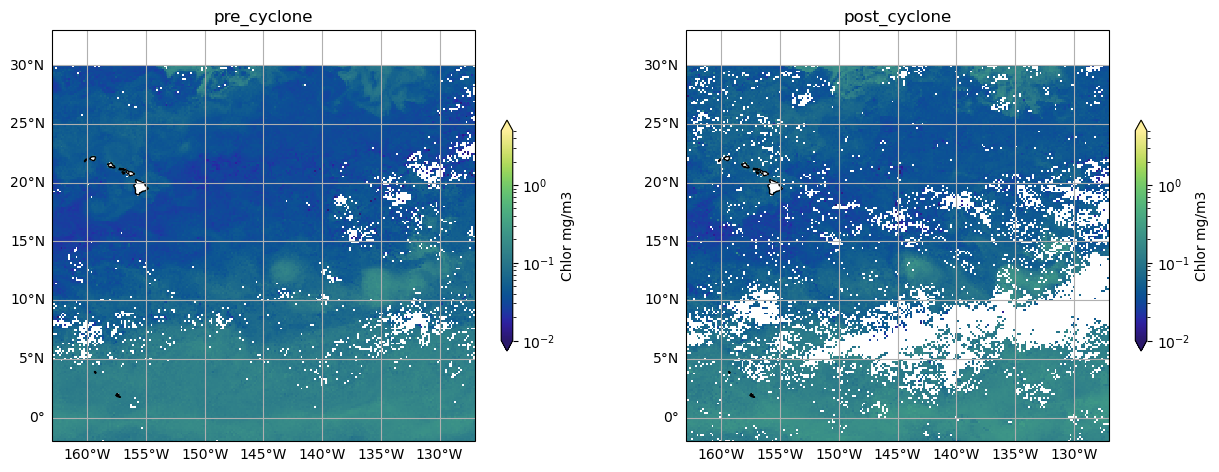

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax[0].gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = pre_data.mean("time").plot(x="longitude", y="latitude" , cbar_kwargs={'label': 'Chlor mg/m3', 'shrink':0.5}, cmap=cmocean.cm.haline,norm=LogNorm(vmin=.01, vmax=5),  ax=ax[0], robust=True)
ax[0].set_xlim(bbox[0]-3,bbox[2]+3,)
ax[0].set_ylim(bbox[1]-3,bbox[3]+3)
ax[0].coastlines()
ax[0].set_title('pre_cyclone')


ax[1].gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = post_data.mean("time").plot(x="longitude", y="latitude", cbar_kwargs={'label': 'Chlor mg/m3', 'shrink':0.5}, cmap=cmocean.cm.haline,norm=LogNorm(vmin=.01, vmax=5),  ax=ax[1], robust=True)
ax[1].set_xlim(bbox[0]-3,bbox[2]+3,)
ax[1].set_ylim(bbox[1]-3,bbox[3]+3)
ax[1].coastlines()
ax[1].set_title('post_cyclone')


Text(0.5, 1.0, 'Percent Change in Chlorphyll-a [%]')

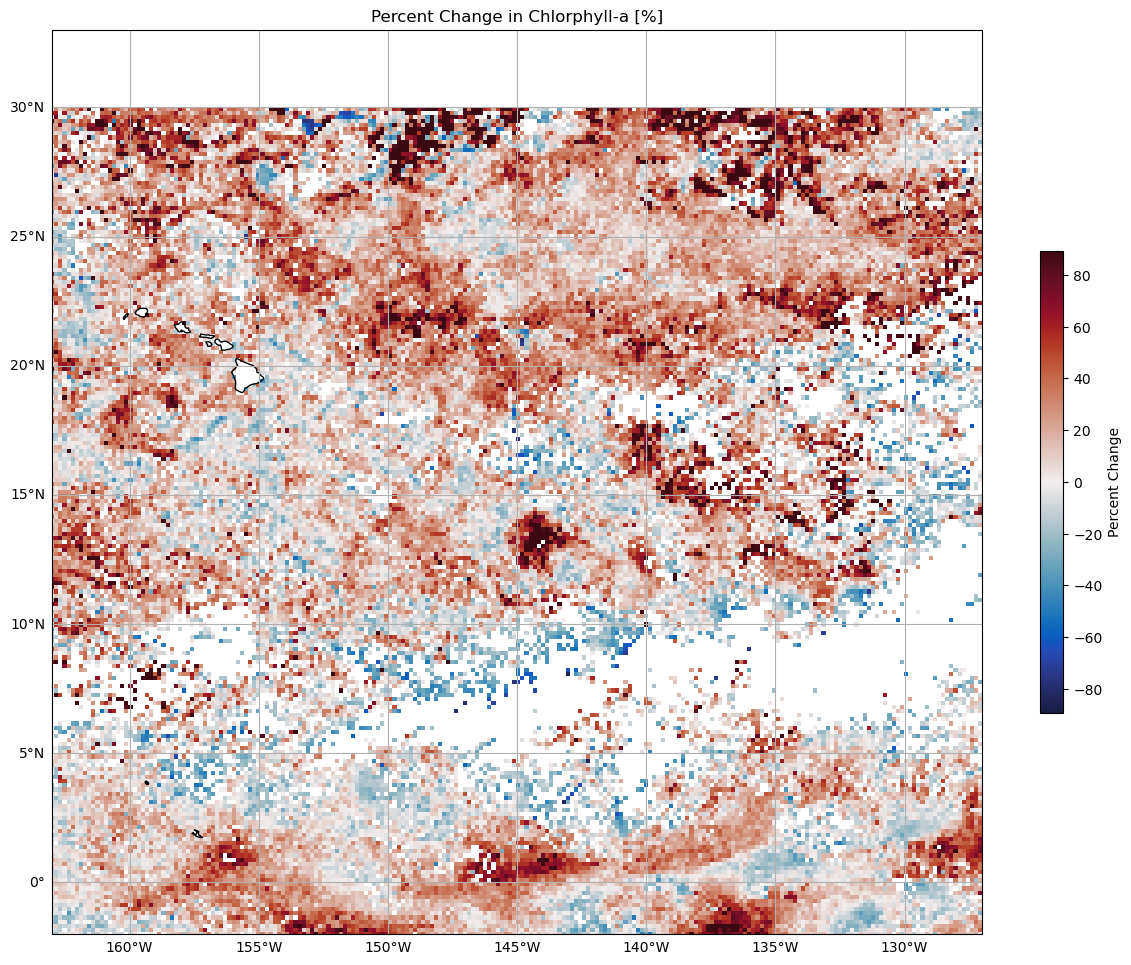

In [8]:
# compare the pre and post event data. first, mask both to only pixels where data is available before and after the hurricane
# then, mask each where it's values are greater or less than

pre_mean = pre_data.mean("time")
post_mean = post_data.mean("time")

post_mean['longitude'] = post_mean['longitude'].round(5)# round lat/lon to 5 decimals, was having issues with floats at large # of decimals not being exactly the same
post_mean['latitude'] = post_mean['latitude'].round(5)
pre_mean['longitude'] = pre_mean['longitude'].round(5)
pre_mean['latitude'] = pre_mean['latitude'].round(5)

# Create a mask where both datasets have valid values
mask = ~np.isnan(post_mean) & ~np.isnan(pre_mean)

# Apply mask to both datasets
post_mean_mask = post_mean.where(mask)
pre_mean_mask = pre_mean.where(mask)

post_greater = (post_mean_mask-pre_mean_mask)/pre_mean_mask * 100

fig, ax = plt.subplots( figsize=(15, 12), subplot_kw={'projection': ccrs.PlateCarree()})
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = post_greater.plot(x="longitude", y="latitude" , cbar_kwargs={'label': 'Percent Change', 'shrink':0.5}, cmap=cmocean.cm.balance, extend = "neither", ax=ax, robust=True)
ax.set_xlim(bbox[0]-3,bbox[2]+3)
ax.set_ylim(bbox[1]-3,bbox[3]+3)
ax.coastlines()
ax.set_title('Percent Change in Chlorphyll-a [%]')


In [9]:
# Finally, the same analysis, but for AVW

pre_tspan = ("2025-09-01", "2025-09-08")    # define your pre-event and post-event timespans
post_tspan = ("2025-09-09", "2025-09-12")

min_lon = -160      # Set lat/lon extent for area of interest
min_lat = 1
max_lon = -130
max_lat = 30

suite_name="PACE_OCI_L2_AOP_NRT" # oci suite name
var_name = "avw" # variable of interest

in_the_cloud = False # set to true if crunning in cloud (e.g. Cryocloud), false if running locally. For speed, granules will be downloaded to a local_data directory when set to false

# do the earthdata search
bbox = (min_lon, min_lat, max_lon, max_lat)
if in_the_cloud == False:
    os.makedirs('local_data/', exist_ok=True)# if not in the cloud, make a folder to downlad granules to. This folder is configured in the .gitignore to not be tracked

pre_results = earthaccess.search_data(
    short_name=suite_name,
    temporal=pre_tspan,
    bounding_box=bbox,
)
print(" Number of pre-event granules: "+str(len(pre_results)))

post_results = earthaccess.search_data(
    short_name=suite_name,
    temporal=post_tspan,
    bounding_box=bbox,
)
print(" Number of post-event granules: "+str(len(post_results)))

# in running this script in the cloud, earthaccess.open is fast, but when running locally it takes a long time (10+ min), and locally downloading the data is faster.
# so, get the data with different approaches, depening on whether you are in the cloud or not, defined above
if in_the_cloud == True:
    pre_paths = earthaccess.open(pre_results)
    post_paths = earthaccess.open(post_results)
else:
    pre_paths = earthaccess.download(pre_results, local_path="local_data/")
    post_paths = earthaccess.download(post_results, local_path="local_data/")
    print('Files Downloaded')

crs, shape, transform = load_first(pre_paths[0], var_name)# once set, dont need to rerun for other vars in same suite
pre_data = coregister_granules(pre_paths, crs, shape, transform, var_name)
post_data = coregister_granules(post_paths, crs, shape, transform, var_name)

 Number of pre-event granules: 51
 Number of post-event granules: 28


QUEUEING TASKS | :   0%|          | 0/51 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/51 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/51 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/28 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/28 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/28 [00:00<?, ?it/s]

Files Downloaded


C:\Users\gtrolley\AppData\Local\Temp\ipykernel_9108\218981918.py:40: FutureWarning: In a future version, xarray will not decode the variable 'day' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  datatree = xr.open_datatree(path)
C:\Users\gtrolley\AppData\Local\Temp\ipykernel_9108\218981918.py:40: FutureWarning: In a future version, xarray will not decode the variable 'msec' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's

loaded pre event files
loaded pre event files


In [14]:
# functions to make wavelength-accurate avw colormap, no need to change
def wavelength_to_rgb(wavelength):
    """
    Convert a wavelength in the range 380-750 nm to an RGB color.
    Source: http://www.had2know.com/technology/rgb-color-wavelength-conversion.html
    """
    gamma = 0.8
    intensity_max = 255

    if (wavelength >= 380) and (wavelength < 440):
        R = -(wavelength - 440) / (440 - 380)
        G = 0.0
        B = 1.0
    elif (wavelength >= 440) and (wavelength < 490):
        R = 0.0
        G = (wavelength - 440) / (490 - 440)
        B = 1.0
    elif (wavelength >= 490) and (wavelength < 510):
        R = 0.0
        G = 1.0
        B = -(wavelength - 510) / (510 - 490)
    elif (wavelength >= 510) and (wavelength < 580):
        R = (wavelength - 510) / (580 - 510)
        G = 1.0
        B = 0.0
    elif (wavelength >= 580) and (wavelength < 645):
        R = 1.0
        G = -(wavelength - 645) / (645 - 580)
        B = 0.0
    elif (wavelength >= 645) and (wavelength <= 750):
        R = 1.0
        G = 0.0
        B = 0.0
    else:
        R = G = B = 0.0

    # Adjust intensity and apply gamma correction
    R = round(intensity_max * (R**gamma))/255
    G = round(intensity_max * (G**gamma))/255
    B = round(intensity_max * (B**gamma))/255

    return (R, G, B)

def generate_colormap(min_wavelength=380, max_wavelength=750, num_colors=256):
    """
    Generates a colormap for wavelengths between `min_wavelength` and `max_wavelength`.
    """
    # Ensure the wavelengths are within the visible range
    min_wavelength = max(min_wavelength, 380)
    max_wavelength = min(max_wavelength, 750)

    # Generate a list of wavelengths between min and max
    wavelengths = np.linspace(min_wavelength, max_wavelength, num_colors)
    #print(wavelengths)
    # Convert wavelengths to RGB colors
    colors = [wavelength_to_rgb(w) for w in wavelengths]
    #print(colors)
    # Create a LinearSegmentedColormap using the RGB colors
    cmap_ = LinearSegmentedColormap.from_list("wavelength_cmap", colors, num_colors)
    return cmap_

400 700


Text(0.5, 1.0, 'post_hurricane 8/21')

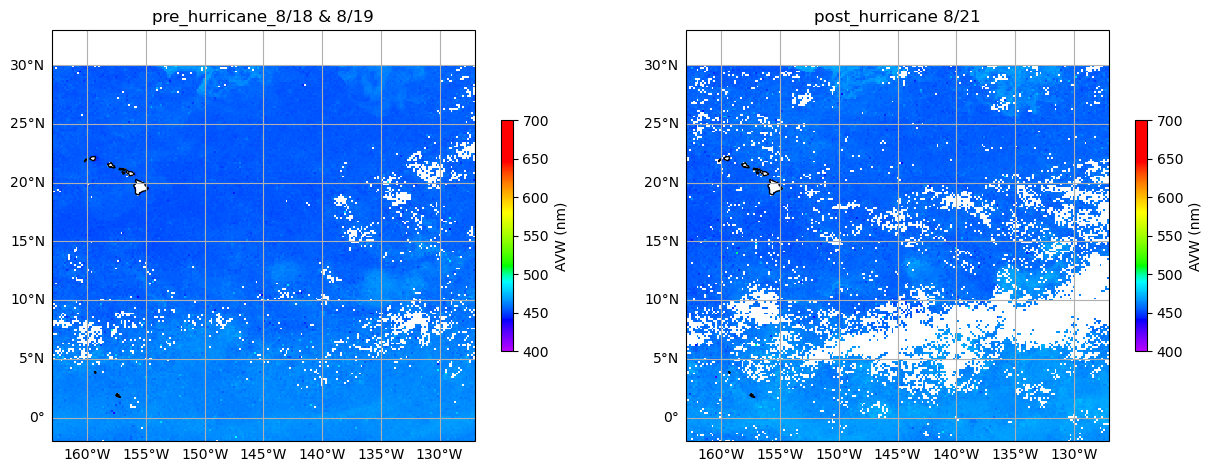

In [15]:
avw_max = 700 # set max/min values for wavelength accurate cmap to build. use these to set vmin/vmax in your calls to xarray.plot as well
avw_min = 400
print(avw_min, avw_max)
my_cmap=generate_colormap(min_wavelength=avw_min, max_wavelength=avw_max, num_colors=256)
my_cmap

pre_data_mean = pre_data.mean("time")
post_data_mean = post_data.mean("time")

fig, ax = plt.subplots(1, 2, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax[0].gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = pre_data_mean.plot(x="longitude", y="latitude" , cbar_kwargs={'label': 'AVW (nm)', 'shrink':0.5}, vmin = avw_min, vmax = avw_max, cmap=my_cmap,  ax=ax[0], robust=True, extend="neither")
ax[0].set_xlim(bbox[0]-3,bbox[2]+3,)
ax[0].set_ylim(bbox[1]-3,bbox[3]+3)
ax[0].coastlines()
ax[0].set_title('pre_hurricane_8/18 & 8/19')


ax[1].gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = post_data_mean.plot(x="longitude", y="latitude", cbar_kwargs={'label': 'AVW (nm)', 'shrink':0.5}, vmin = avw_min, vmax = avw_max, cmap=my_cmap,  ax=ax[1], robust=True, extend="neither")
ax[1].set_xlim(bbox[0]-3,bbox[2]+3,)
ax[1].set_ylim(bbox[1]-3,bbox[3]+3)
ax[1].coastlines()
ax[1].set_title('post_hurricane 8/21')

Text(0.5, 1.0, 'Change in AVW')

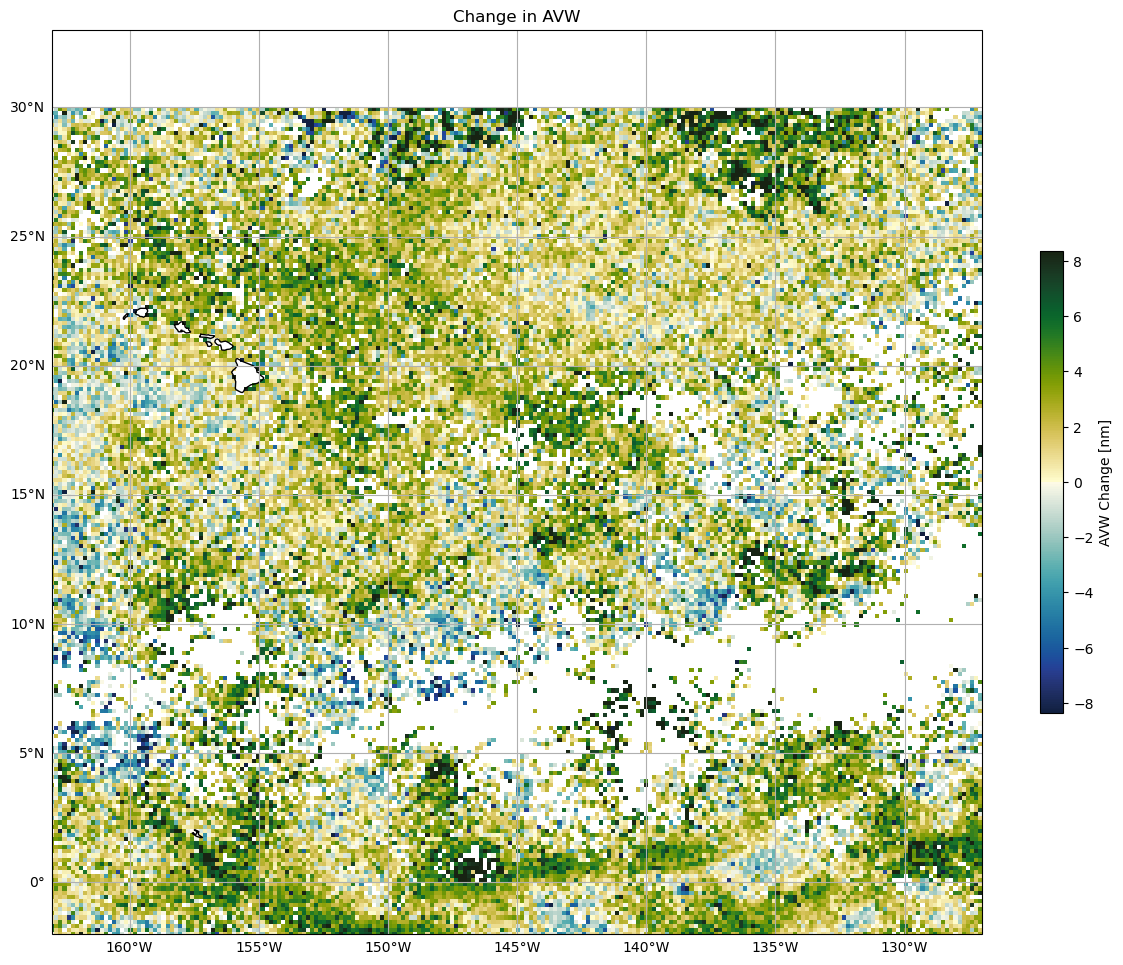

In [16]:
# compare the pre and post event data. first, mask both to only pixels where data is available before and after the hurricane
# then, mask each where it's values are greater or less than

pre_mean = pre_data.mean("time")
post_mean = post_data.mean("time")

post_mean['longitude'] = post_mean['longitude'].round(5)# round lat/lon to 5 decimals, was having issues with floats at large # of decimals not being exactly the same
post_mean['latitude'] = post_mean['latitude'].round(5)
pre_mean['longitude'] = pre_mean['longitude'].round(5)
pre_mean['latitude'] = pre_mean['latitude'].round(5)

# Create a mask where both datasets have valid values
mask = ~np.isnan(post_mean) & ~np.isnan(pre_mean)

# Apply mask to both datasets
post_mean_mask = post_mean.where(mask)
pre_mean_mask = pre_mean.where(mask)

post_greater = post_mean_mask-pre_mean_mask

fig, ax = plt.subplots( figsize=(15, 12), subplot_kw={'projection': ccrs.PlateCarree()})
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = post_greater.plot(x="longitude", y="latitude" , cbar_kwargs={'label': 'AVW Change [nm]', 'shrink':0.5}, cmap=cmocean.cm.delta, extend = "neither", ax=ax, robust=True)
ax.set_xlim(bbox[0]-3,bbox[2]+3,)
ax.set_ylim(bbox[1]-3,bbox[3]+3)
ax.coastlines()
ax.set_title('Change in AVW')